In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.ensemble import StackingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)

In [2]:
df = pd.read_csv("../data/novagen_dataset.csv")

In [4]:
X = df.drop("Target", axis=1)
y = df["Target"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Import fitted preprocessor and fit X_train, X_test data

In [8]:
preprocessor = joblib.load("../models/preprocessor.pkl")

# X_train_processed = preprocessor.transform(X_train)
# X_test_processed = preprocessor.transform(X_test)

# Create stacking classification model

In [9]:
estimators = [
    ("lr", LogisticRegression(max_iter=1000)),
    ("rf", RandomForestClassifier(
        n_estimators=300,
        max_depth=5,
        random_state=42
    )),
    ("xgb", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="logloss"
    ))
]

stacking_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5,
    n_jobs=-1
)


,estimators,"[('lr', ...), ('rf', ...), ...]"
,final_estimator,LogisticRegression()
,cv,5
,stack_method,'auto'
,n_jobs,-1
,passthrough,False
,verbose,0
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


# Create pipeline for processing and fitting

In [11]:
stacking_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("stacking", stacking_clf)
])

In [15]:
stacking_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('stacking', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [16]:
y_pred = stacking_pipeline.predict(X_test)

# Evaluation

In [25]:
y_prob = stacking_pipeline.predict_proba(X_test)[:, 1]

auc_score = roc_auc_score(y_test, y_prob)

print("Accuracy Score: ", accuracy_score(y_test, y_pred))
print("ROC-AUC Score: ", auc_score)
print("Classification Report: \n", classification_report(y_test, y_pred))

Accuracy Score:  0.9476439790575916
ROC-AUC Score:  0.9878276783281924
Classification Report: 
               precision    recall  f1-score   support

           0       0.96      0.93      0.94       914
           1       0.94      0.96      0.95       996

    accuracy                           0.95      1910
   macro avg       0.95      0.95      0.95      1910
weighted avg       0.95      0.95      0.95      1910



# Confusion Matrix

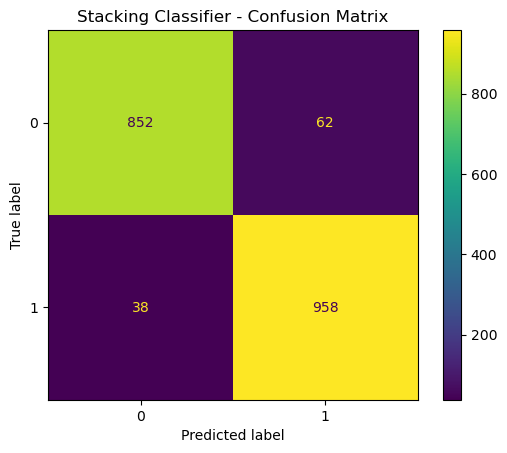

In [26]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm
)

disp.plot()
plt.title("Stacking Classifier - Confusion Matrix")
plt.show()

# ROC Curve

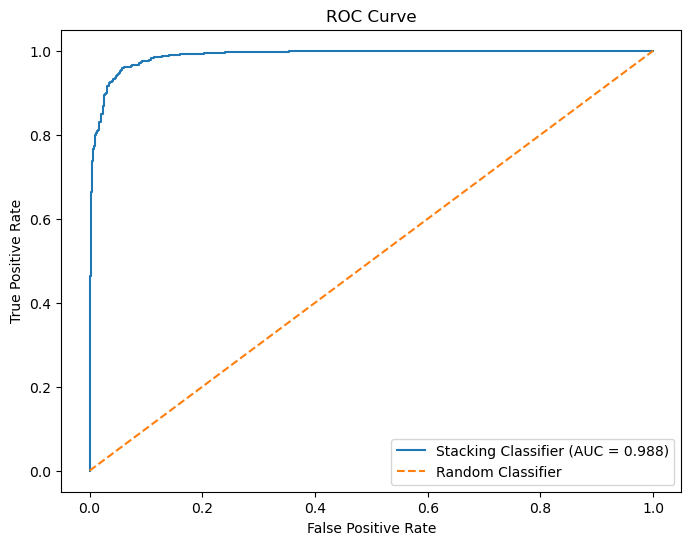

In [27]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"Stacking Classifier (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [23]:
joblib.dump(
    stacking_pipeline,
    "../models/stacking_pipeline.pkl"
)

['../models/stacking_pipeline.pkl']